In [75]:
import pandas as pd
import numpy as np

csv = pd.read_csv("encuestas.csv")

conversion = {
    "Nunca": 1,
    "Algunas veces al Año": 2,
    "Algunas veces al Mes": 3,
    "Algunas veces a la Semana": 4,
    "Diariamente": 5
    }

for col in csv.columns[1:23]:
    csv[col] = csv[col].map(conversion)


# Agotamiento emocional
AE_cols = [
    csv.columns[1],
    csv.columns[2],
    csv.columns[3],
    csv.columns[6],
    csv.columns[8],
    csv.columns[13],
    csv.columns[14],
    csv.columns[16],
    csv.columns[20]
]


# Despersonalización
DP_cols = [
    csv.columns[5],
    csv.columns[10],
    csv.columns[11],
    csv.columns[15],
    csv.columns[22]
]


# Realización personal
RP_cols = [
    csv.columns[4],
    csv.columns[7],
    csv.columns[9],
    csv.columns[12],
    csv.columns[17],
    csv.columns[18],
    csv.columns[19],
    csv.columns[21]
]


csv["AE_total"] = csv[AE_cols].sum(axis=1)

csv["DP_total"] = csv[DP_cols].sum(axis=1)

csv["RP_total"] = csv[RP_cols].sum(axis=1)



p25_AE = np.percentile(csv["AE_total"], 25)
p75_AE = np.percentile(csv["AE_total"], 75)

p25_DP = np.percentile(csv["DP_total"], 25)
p75_DP = np.percentile(csv["DP_total"], 75)

p25_RP = np.percentile(csv["RP_total"], 25)
p75_RP = np.percentile(csv["RP_total"], 75)
    



# Agotamiento emocional
for i in range(len(csv)):

    valor = csv.loc[i, "AE_total"]

    if valor < p25_AE:
        csv.loc[i, "AE_nivel"] = "Bajo"

    elif valor > p75_AE:
        csv.loc[i, "AE_nivel"] = "Alto"

    else:
        csv.loc[i, "AE_nivel"] = "Medio"


# Despersonalización
for i in range(len(csv)):

    valor = csv.loc[i, "DP_total"]

    if valor < p25_DP:
        csv.loc[i, "DP_nivel"] = "Bajo"

    elif valor > p75_DP:
        csv.loc[i, "DP_nivel"] = "Alto"

    else:
        csv.loc[i, "DP_nivel"] = "Medio"


# Realización personal
for i in range(len(csv)):

    valor = csv.loc[i, "RP_total"]

    if valor < p25_RP:
        csv.loc[i, "RP_nivel"] = "Bajo"

    elif valor > p75_RP:
        csv.loc[i, "RP_nivel"] = "Alto"

    else:
        csv.loc[i, "RP_nivel"] = "Medio"






print("AE:", p25_AE, p75_AE)
print("DP:", p25_DP, p75_DP)
print("RP:", p25_RP, p75_RP)

print(csv[["AE_total", "AE_nivel", "DP_total", "DP_nivel", "RP_total", "RP_nivel"]])

AE: 23.0 34.0
DP: 8.0 15.0
RP: 28.0 35.0
    AE_total AE_nivel  DP_total DP_nivel  RP_total RP_nivel
0         15     Bajo         7     Bajo        37     Alto
1         21     Bajo         5     Bajo        37     Alto
2         42     Alto        15    Medio        25     Bajo
3         29    Medio         9    Medio        33    Medio
4         32    Medio        13    Medio        28    Medio
5         19     Bajo        16     Alto        36     Alto
6         28    Medio        13    Medio        21     Bajo
7         12     Bajo         5     Bajo        38     Alto
8         31    Medio        21     Alto        15     Bajo
9         31    Medio        16     Alto        23     Bajo
10        34    Medio        12    Medio        31    Medio
11        28    Medio        17     Alto        32    Medio
12        41     Alto        21     Alto        32    Medio
13        30    Medio        15    Medio        28    Medio
14        17     Bajo         8    Medio        36     Alto

In [68]:
#con lo que no son nuestros percentiles:

for i in range(len(csv)):

    valor = csv.loc[i, "AE_total"]

    if valor < 22:
        csv.loc[i, "AE_nivel2"] = "Bajo"

    elif valor > 26:
        csv.loc[i, "AE_nivel2"] = "Alto"

    else:
        csv.loc[i, "AE_nivel2"] = "Medio"


for i in range(len(csv)):

    valor = csv.loc[i, "DP_total"]

    if valor < 9:
        csv.loc[i, "DP_nivel2"] = "Bajo"

    elif valor > 11:
        csv.loc[i, "DP_nivel2"] = "Alto"

    else:
        csv.loc[i, "DP_nivel2"] = "Medio"


for i in range(len(csv)):

    valor = csv.loc[i, "RP_total"]

    if valor < 31:
        csv.loc[i, "RP_nivel2"] = "Bajo"

    elif valor > 34:
        csv.loc[i, "RP_nivel2"] = "Alto"

    else:
        csv.loc[i, "RP_nivel2"] = "Medio"


print(csv[["AE_nivel2", "AE_nivel", "DP_nivel2", "DP_nivel", "RP_nivel2", "RP_nivel"]])

   AE_nivel2 AE_nivel DP_nivel2 DP_nivel RP_nivel2 RP_nivel
0       Bajo     Bajo      Bajo     Bajo      Alto     Alto
1       Bajo     Bajo      Bajo     Bajo      Alto     Alto
2       Alto     Alto      Alto    Medio      Bajo     Bajo
3       Alto    Medio     Medio    Medio     Medio    Medio
4       Alto    Medio      Alto    Medio      Bajo    Medio
5       Bajo     Bajo      Alto     Alto      Alto     Alto
6       Alto    Medio      Alto    Medio      Bajo     Bajo
7       Bajo     Bajo      Bajo     Bajo      Alto     Alto
8       Alto    Medio      Alto     Alto      Bajo     Bajo
9       Alto    Medio      Alto     Alto      Bajo     Bajo
10      Alto    Medio      Alto    Medio     Medio    Medio
11      Alto    Medio      Alto     Alto     Medio    Medio
12      Alto     Alto      Alto     Alto     Medio    Medio
13      Alto    Medio      Alto    Medio      Bajo    Medio
14      Bajo     Bajo      Bajo    Medio      Alto     Alto
15     Medio    Medio      Bajo     Bajo

In [69]:
#para uwes

csv = pd.read_csv("encuestas.csv")

conversion2 = {
    "Nunca": 0,
    "Algunas veces al Año": 1,
    "Una vez por Mes": 2,
    "Algunas veces al Mes": 3,
    "Una vez por Semana": 4,
    "Algunas veces a la Semana": 5,
    "Diariamente": 6
    }

for col in csv.columns[23:32]:
    csv[col] = csv[col].map(conversion2)


# VigorS
Vig_cols = [
    csv.columns[23],
    csv.columns[24],
    csv.columns[27]
]


# Dedicación
Ded_cols = [
    csv.columns[25],
    csv.columns[26],
    csv.columns[29],
]


# Absorción
Abs_cols = [
    csv.columns[28],
    csv.columns[30],
    csv.columns[31],
]



csv["Vig_media"] = round(csv[Vig_cols].mean(axis=1),2)

csv["Ded_media"] = round(csv[Ded_cols].mean(axis=1),2)

csv["Abs_media"] = round(csv[Abs_cols].mean(axis=1),2)


p5_Vig = np.percentile(csv["Vig_media"], 5)
p25_Vig = np.percentile(csv["Vig_media"], 25)
p75_Vig = np.percentile(csv["Vig_media"], 75)
p95_Vig = np.percentile(csv["Vig_media"], 95)

p5_Ded = np.percentile(csv["Ded_media"], 5)
p25_Ded = np.percentile(csv["Ded_media"], 25)
p75_Ded = np.percentile(csv["Ded_media"], 75)
p95_Ded = np.percentile(csv["Ded_media"], 95)

p5_Abs = np.percentile(csv["Abs_media"], 5)
p25_Abs = np.percentile(csv["Abs_media"], 25)
p75_Abs = np.percentile(csv["Abs_media"], 75)
p95_Abs = np.percentile(csv["Abs_media"], 95)



# Vigor
for i in range(len(csv)):

    valor = csv.loc[i, "Vig_media"]

    if valor < p5_Vig:
        csv.loc[i, "Vig_nivel"] = "Muy Bajo"
        
    elif valor < p25_Vig:
        csv.loc[i, "Vig_nivel"] = "Bajo"

    elif valor < p75_Vig:
        csv.loc[i, "Vig_nivel"] = "Medio"
        
    elif valor < p95_Vig:
        csv.loc[i, "Vig_nivel"] = "Alto"

    else:
        csv.loc[i, "Vig_nivel"] = "Muy alto"


# Dedicación
for i in range(len(csv)):

    valor = csv.loc[i, "Ded_media"]

    if valor < p5_Ded:
        csv.loc[i, "Ded_nivel"] = "Muy Bajo"
        
    elif valor < p25_Ded:
        csv.loc[i, "Ded_nivel"] = "Bajo"

    elif valor < p75_Ded:
        csv.loc[i, "Ded_nivel"] = "Medio"
        
    elif valor < p95_Ded:
        csv.loc[i, "Ded_nivel"] = "Alto"

    else:
        csv.loc[i, "Ded_nivel"] = "Muy alto"


# Absorción
for i in range(len(csv)):

    valor = csv.loc[i, "Abs_media"]

    if valor < p5_Abs:
        csv.loc[i, "Abs_nivel"] = "Muy Bajo"
        
    elif valor < p25_Abs:
        csv.loc[i, "Abs_nivel"] = "Bajo"

    elif valor < p75_Abs:
        csv.loc[i, "Abs_nivel"] = "Medio"
        
    elif valor < p95_Abs:
        csv.loc[i, "Abs_nivel"] = "Alto"

    else:
        csv.loc[i, "Abs_nivel"] = "Muy alto"






print("Vig:", p5_Vig, p25_Vig, p75_Vig, p95_Vig)
print("Ded:", p5_Ded, p25_Ded, p75_Ded, p95_Ded)
print("Abs:", p5_Abs, p25_Abs, p75_Abs, p95_Abs)

print(csv[["Vig_media", "Vig_nivel", "Ded_media", "Ded_nivel", "Abs_media", "Abs_nivel"]])

Vig: 1.67 3.0 5.33 6.0
Ded: 0.8680000000000001 3.33 5.67 6.0
Abs: 1.8679999999999999 3.33 5.33 5.802
    Vig_media Vig_nivel  Ded_media Ded_nivel  Abs_media Abs_nivel
0        6.00  Muy alto       6.00  Muy alto       3.67     Medio
1        3.67     Medio       5.33     Medio       1.67  Muy Bajo
2        0.00  Muy Bajo       0.00  Muy Bajo       4.00     Medio
3        5.33      Alto       5.67      Alto       5.33      Alto
4        2.67      Bajo       4.00     Medio       4.00     Medio
5        6.00  Muy alto       6.00  Muy alto       5.00     Medio
6        0.00  Muy Bajo       2.00      Bajo       2.00      Bajo
7        6.00  Muy alto       6.00  Muy alto       6.00  Muy alto
8        1.67      Bajo       0.00  Muy Bajo       0.00  Muy Bajo
9        1.67      Bajo       2.00      Bajo       2.00      Bajo
10       2.33      Bajo       3.67     Medio       3.67     Medio
11       4.67     Medio       4.67     Medio       5.00     Medio
12       3.00     Medio       4.67     Me

In [23]:
# Vigor
for i in range(len(csv)):

    valor = csv.loc[i, "Vig_media"]

    if valor <= 2:
        csv.loc[i, "Vig_nivel2"] = "Muy Bajo"
        
    elif valor < 3.25:
        csv.loc[i, "Vig_nivel2"] = "Bajo"

    elif valor < 4.8:
        csv.loc[i, "Vig_nivel2"] = "Medio"
        
    elif valor < 5.65:
        csv.loc[i, "Vig_nivel2"] = "Alto"

    else:
        csv.loc[i, "Vig_nivel2"] = "Muy alto"


# Dedicación
for i in range(len(csv)):

    valor = csv.loc[i, "Ded_media"]

    if valor <= 1.33:
        csv.loc[i, "Ded_nivel2"] = "Muy Bajo"
        
    elif valor < 2.9:
        csv.loc[i, "Ded_nivel2"] = "Bajo"

    elif valor < 4.7:
        csv.loc[i, "Ded_nivel2"] = "Medio"
        
    elif valor < 5.69:
        csv.loc[i, "Ded_nivel2"] = "Alto"

    else:
        csv.loc[i, "Ded_nivel2"] = "Muy alto"


# Absorción
for i in range(len(csv)):

    valor = csv.loc[i, "Abs_media"]

    if valor <= 1.77:
        csv.loc[i, "Abs_nivel2"] = "Muy Bajo"
        
    elif valor < 2.33:
        csv.loc[i, "Abs_nivel2"] = "Bajo"

    elif valor < 4.2:
        csv.loc[i, "Abs_nivel2"] = "Medio"
        
    elif valor < 5.33:
        csv.loc[i, "Abs_nivel2"] = "Alto"

    else:
        csv.loc[i, "Abs_nivel2"] = "Muy alto"


print(csv[["Vig_nivel2", "Vig_nivel", "Ded_nivel2", "Ded_nivel", "Abs_nivel2", "Abs_nivel"]])

   Vig_nivel2 Vig_nivel Ded_nivel2 Ded_nivel Abs_nivel2 Abs_nivel
0    Muy alto  Muy alto   Muy alto  Muy alto      Medio     Medio
1       Medio     Medio       Alto     Medio   Muy Bajo  Muy Bajo
2    Muy Bajo  Muy Bajo   Muy Bajo  Muy Bajo      Medio     Medio
3        Alto      Alto       Alto      Alto   Muy alto      Alto
4        Bajo      Bajo      Medio     Medio      Medio     Medio
5    Muy alto  Muy alto   Muy alto  Muy alto       Alto     Medio
6    Muy Bajo  Muy Bajo       Bajo      Bajo       Bajo      Bajo
7    Muy alto  Muy alto   Muy alto  Muy alto   Muy alto  Muy alto
8    Muy Bajo      Bajo   Muy Bajo  Muy Bajo   Muy Bajo  Muy Bajo
9    Muy Bajo      Bajo       Bajo      Bajo       Bajo      Bajo
10       Bajo      Bajo      Medio     Medio      Medio     Medio
11      Medio     Medio      Medio     Medio       Alto     Medio
12       Bajo     Medio      Medio     Medio       Alto     Medio
13   Muy alto  Muy alto   Muy alto  Muy alto   Muy alto  Muy alto
14      Me

In [24]:
!pip install networkx==2.8.8
!pip install scikit-fuzzy
# Libraries
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

C:\Users\Fer-Marcos-Lucas\anaconda3\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


NameError: name 'rule1' is not defined

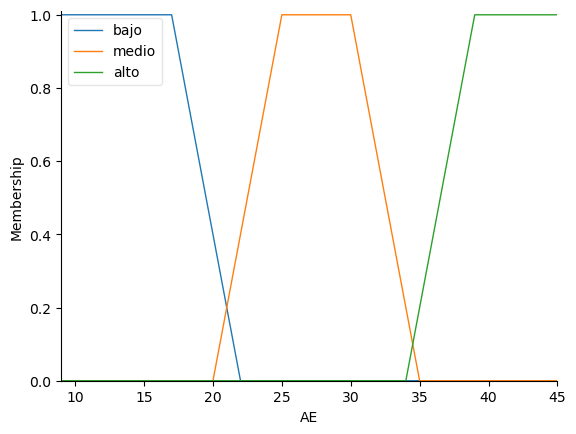

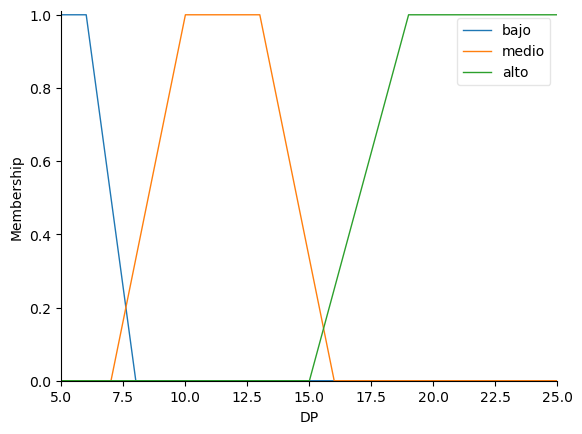

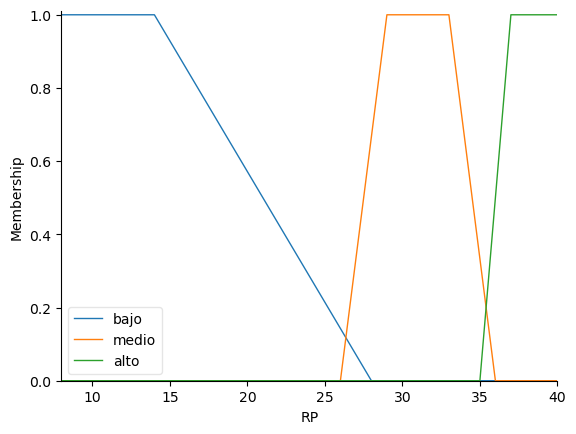

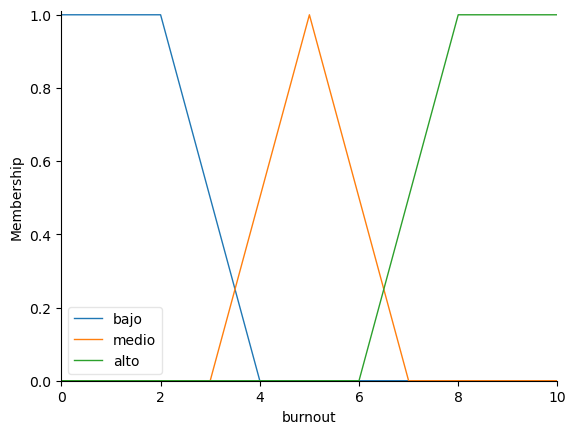

In [25]:
# Definition of input and output variables
AE = ctrl.Antecedent(np.arange(9, 46), 'AE')
DP = ctrl.Antecedent(np.arange(5, 26), 'DP')
RP = ctrl.Antecedent(np.arange(8, 41), 'RP')

burnout = ctrl.Consequent(np.arange(0, 11), 'burnout') #si fuera 0,10 generaría números hasta el 9, estamos siempre poniendo 1 más

'''
AE: 23 33 -> 33-23 = 10 -> usando 25%: 2.5 -> 3 (explico cómo es esto del % luego)
DP: 8 15 -> 15-8 = 7 -> 1.75 -> 2 
RP: 28 35 -> 35-28 = 7 -> 2
'''
#distancia intercuartílica
AE['bajo']  = fuzz.trapmf(AE.universe, [9,  9,  17, 22])   # 22 + 5
AE['medio'] = fuzz.trapmf(AE.universe, [20, 25, 30, 35])   # 22 - 5, 32 + 5
AE['alto']  = fuzz.trapmf(AE.universe, [34, 39, 45, 45])   # 32 - 5
AE.view()

DP['bajo'] = fuzz.trapmf(DP.universe, [5, 5, 6, 8])
DP['medio'] = fuzz.trapmf(DP.universe, [7, 10, 13, 16])
DP['alto'] = fuzz.trapmf(DP.universe, [15, 19, 25, 25])
DP.view()

RP['bajo'] = fuzz.trapmf(RP.universe, [8, 8, 14, 28])
RP['medio'] = fuzz.trapmf(RP.universe, [26, 29, 33, 36])
RP['alto'] = fuzz.trapmf(RP.universe, [35, 37, 40, 40])
RP.view()

#cortes simétricos del 0 al 10
burnout['bajo']  = fuzz.trapmf(burnout.universe, [0, 0, 2, 4])
burnout['medio'] = fuzz.trapmf(burnout.universe, [3, 5, 5, 7])
burnout['alto']  = fuzz.trapmf(burnout.universe, [6, 8, 10, 10])
burnout.view()
'''

AE['bajo']  = fuzz.trapmf(AE.universe, [9,  9,  22, 25])   # 22 + 5
AE['medio'] = fuzz.trapmf(AE.universe, [22, 22, 32, 32])   # 22 - 5, 32 + 5
AE['alto']  = fuzz.trapmf(AE.universe, [29, 32, 45, 45])   # 32 - 5
AE.view()

DP['bajo'] = fuzz.trapmf(DP.universe, [5, 5, 8, 10])
DP['medio'] = fuzz.trapmf(DP.universe, [8, 8, 15, 15])
DP['alto'] = fuzz.trapmf(DP.universe, [13, 15, 25, 25])
DP.view()

RP['bajo'] = fuzz.trapmf(RP.universe, [8, 8, 28, 30])
RP['medio'] = fuzz.trapmf(RP.universe, [28, 28, 36, 36])
RP['alto'] = fuzz.trapmf(RP.universe, [34, 36, 40, 40])
RP.view()

#cortes simétricos del 0 al 10
burnout['bajo']  = fuzz.trapmf(burnout.universe, [0, 0, 1, 4])
burnout['medio'] = fuzz.trapmf(burnout.universe, [3, 4, 6, 8])
burnout['alto']  = fuzz.trapmf(burnout.universe, [6, 9, 10, 10])
burnout.view()
'''
'''
#reglas
rule1 = ctrl.Rule(AE['alto'] & DP['alto'] & RP['bajo'], burnout['alto'])
rule2 = ctrl.Rule(AE['bajo'] & DP['bajo'] & RP['alto'], burnout['bajo'])

rule3 = ctrl.Rule(AE['medio'] | DP['medio'] | RP['medio'], burnout['medio']) #con cualquiera en medio -> burnout medio

#ahora el problema, al no estar "medio", es más fácil y no hay que hacer muchas variables para tener todos los casos
#además, como con que una no se cumpla no importa saber lo demás, es un problema muy sencillo con 2 opciones y 2 variables (4 combinaciones)
#lo de arriba creo que está mal explicado, preguntar el sentido lógico/matemático de que ahora sean 4 porque tenemos aún tres variables
#a partir de aquí los casos en los que ya no se cumpla el burnout alto o bajo lo dejamos en medio, esto engloba todas las posibles combinaciones

rule4 = ctrl.Rule(AE['alto'] & DP['bajo'], burnout['medio']) #AE alto + DP bajo (RP ya no importa)
rule5 = ctrl.Rule(RP['alto'] & AE['alto'], burnout['medio']) #AE alto + RP alto (DP ya no importa)
rule6 = ctrl.Rule(AE['bajo'] & DP['alto'], burnout['medio']) #AE bajo + DP alto (RP ya no importa)
rule7 = ctrl.Rule(RP['bajo'] & AE['bajo'], burnout['medio']) #AE bajo + RP bajo (DP ya no importa)
'''
'''
#si las negativas están en un extremo y la positiva no está en el mismo -> ponemos ese extremo
rule1 = ctrl.Rule(AE['alto'] & DP['alto'] & (RP['bajo'] | RP['medio']), burnout['alto'])
rule2 = ctrl.Rule(AE['bajo'] & DP['bajo'] & (RP['alto'] | RP['medio']), burnout['bajo'])

#si la positiva está en el mismo extremo que las negativas -> medio
rule3 = ctrl.Rule(AE['bajo'] & DP['bajo'] & RP['bajo'], burnout['medio'])
rule4 = ctrl.Rule(AE['alto'] & DP['alto'] & RP['alto'], burnout['medio'])

#si al menos dos están en medio -> medio
rule5 = ctrl.Rule(DP['medio'] & RP['medio'], burnout['medio'])
rule6 = ctrl.Rule(AE['medio'] & RP['medio'], burnout['medio'])
rule7 = ctrl.Rule(AE['medio'] & DP['medio'], burnout['medio'])

#si las negativas están en un extremo distinto y la positiva en medio -> medio
rule8 = ctrl.Rule(AE['alto'] & DP['bajo'] & RP['medio'], burnout['medio'])
rule9 = ctrl.Rule(AE['bajo'] & DP['alto'] & RP['medio'], burnout['medio'])

#si las negativas están en un extremo distinto y la positiva en bajo -> alto
rule10 = ctrl.Rule(AE['alto'] & DP['bajo'] & RP['bajo'], burnout['alto'])
rule11 = ctrl.Rule(AE['bajo'] & DP['alto'] & RP['bajo'], burnout['alto'])

#si las negativas están en un extremo distinto y la positiva en alto -> bajo
rule12 = ctrl.Rule(AE['alto'] & DP['bajo'] & RP['alto'], burnout['bajo'])
rule13 = ctrl.Rule(AE['bajo'] & DP['alto'] & RP['alto'], burnout['bajo'])

#si la positiva no es alto y de las otras una es medio y otro alto -> alto
rule14 = ctrl.Rule(AE['alto'] & DP['medio'] & (RP['bajo'] | RP['medio']), burnout['alto'])
rule15 = ctrl.Rule(AE['medio'] & DP['alto'] & (RP['bajo'] | RP['medio']), burnout['alto'])

#si la positiva no es bajo y de las otras una es medio y otra bajo -> bajo
rule16 = ctrl.Rule(AE['medio'] & DP['bajo'] & (RP['alto'] | RP['medio']), burnout['bajo'])
rule17 = ctrl.Rule(AE['bajo'] & DP['medio'] & (RP['alto'] | RP['medio']), burnout['bajo'])

#si una negativa es medio y las demás en un extremo -> medio 
rule18 = ctrl.Rule(AE['medio'] & ((DP['alto'] & RP['alto']) | (DP['bajo'] & RP['bajo'])) , burnout['medio'])
rule19 = ctrl.Rule(DP['medio'] & ((AE['alto'] & RP['alto']) | (AE['bajo'] & RP['bajo'])), burnout['medio'])

#aunque las reglas 3 y 4 regulen que todo sea bajo o alto para dar medio, da demasiado medio cuando a debería ser más como 2/3 de bajo si
#por ejemplo las negativas son bajas pero la positiva también
rule21 = ctrl.Rule(AE['alto'] & DP['alto'], burnout['alto'])
rule20 = ctrl.Rule(AE['bajo'] & DP['bajo'], burnout['bajo'])

rule21 = ctrl.Rule(AE['alto'] & RP['alto'], burnout['medio'])
rule21 = ctrl.Rule(AE['bajo'] & RP['bajo'], burnout['medio'])

rule21 = ctrl.Rule(DP['alto'] & RP['alto'], burnout['medio'])
rule21 = ctrl.Rule(DP['bajo'] & RP['bajo'], burnout['medio'])
'''


'''
# Fuzzy control system and simulation setup
burnout_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10, rule11, rule12, rule13, rule14,
                                  rule15, rule16, rule17, rule18, rule19, rule20, rule21, rule22, rule23])
'''
burnout_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
type = ctrl.ControlSystemSimulation(burnout_ctrl)
type.input['AE'] = int(input('Agotamiento emocional: '))
type.input['DP'] = int(input('Despersonalización: '))
type.input['RP'] = int(input('Realización personal: '))
type.compute()
print('Burnout:', type.output['burnout'])
burnout.view(sim=type)

In [76]:


import pandas as pd
import random

valores = [
[4,6,6,8,10],
[3,4,6,9,9],
[6,1,0,1,4],
[6,4,5,10,8],
[7,1,10,6,6],
[2,5,8,0,9],
[0,1,1,2,9],
[3,6,8,4,8],
[0,2,4,5,2],
[6,6,8,7,6],
[4,5,9,3,9],
[4,3,8,10,6],
[10,3,2,2,0],
[8,1,2,1,8],
[5,3,6,8,9],
[0,1,3,4,7],
[8,4,2,3,4],
[3,0,1,9,8],
[8,4,7,9,9],
[3,2,6,5,7],
[5,1,3,8,10],
[7,5,4,3,4],
[6,10,7,3,7],
[7,2,4,6,3],
[6,9,7,3,6],
[4,1,4,0,7],
[5,8,5,8,3],
[9,5,8,6,6],
[10,9,7,2,5],
[10,6,6,0,5],
[3,2,3,3,0],
[5,6,8,4,10],
[6,4,0,2,5],
[9,3,6,1,10],
[2,5,6,9,10],
[5,1,2,5,7],
[7,0,6,7,3],
[3,6,1,7,9],
[3,1,4,7,10],
[2,1,8,7,8],
[6,3,5,5,2],
[8,6,0,1,3],
[6,3,5,8,3],
[9,5,5,2,5],
[7,8,8,3,9],
[8,8,1,1,3],
[6,6,6,3,4],
[5,0,8,0,5],
[3,9,1,1,10],
[8,5,4,5,2],
[6,5,5,3,5],
[0,0,6,0,5],
[8,6,10,0,6]
]

for i in range(len(csv)):

    csv.iloc[i, 32] = valores[i][0]
    csv.iloc[i, 33] = valores[i][1]
    csv.iloc[i, 34] = valores[i][2]
    csv.iloc[i, 35] = valores[i][3]
    csv.iloc[i, 36] = valores[i][4]

print(csv.iloc[:, [37,40,38,41,39,42,32,33,34,35,36]].to_string(index=False, header=False))


15  Bajo  7  Bajo 37  Alto  4  6  6  8 10
21  Bajo  5  Bajo 37  Alto  3  4  6  9  9
42  Alto 15 Medio 25  Bajo  6  1  0  1  4
29 Medio  9 Medio 33 Medio  6  4  5 10  8
32 Medio 13 Medio 28 Medio  7  1 10  6  6
19  Bajo 16  Alto 36  Alto  2  5  8  0  9
28 Medio 13 Medio 21  Bajo  0  1  1  2  9
12  Bajo  5  Bajo 38  Alto  3  6  8  4  8
31 Medio 21  Alto 15  Bajo  0  2  4  5  2
31 Medio 16  Alto 23  Bajo  6  6  8  7  6
34 Medio 12 Medio 31 Medio  4  5  9  3  9
28 Medio 17  Alto 32 Medio  4  3  8 10  6
41  Alto 21  Alto 32 Medio 10  3  2  2  0
30 Medio 15 Medio 28 Medio  8  1  2  1  8
17  Bajo  8 Medio 36  Alto  5  3  6  8  9
25 Medio  6  Bajo 36  Alto  0  1  3  4  7
33 Medio 16  Alto 32 Medio  8  4  2  3  4
23 Medio 12 Medio 29 Medio  3  0  1  9  8
22  Bajo 16  Alto 34 Medio  8  4  7  9  9
10  Bajo  5  Bajo 40  Alto  3  2  6  5  7
14  Bajo  8 Medio 32 Medio  5  1  3  8 10
26 Medio 12 Medio 35 Medio  7  5  4  3  4
29 Medio 11 Medio 34 Medio  6 10  7  3  7
32 Medio 15 Medio 28 Medio  7  2  

In [77]:
columna_objetivo = csv.columns[32]

orden_niveles = {
    "Bajo": 1,
    "Medio": 2,
    "Alto": 3
}

# ======================
# AE
# ======================

csv['temp_sort'] = csv['AE_nivel'].map(orden_niveles)

csv_final = csv.sort_values(['temp_sort', columna_objetivo])

print(
    csv_final[["AE_nivel", columna_objetivo]]
    .to_string(index=False, header=False)
)

for nivel in ["Bajo", "Medio", "Alto"]:

    filtrado = csv[csv["AE_nivel"] == nivel]

    suma = filtrado[columna_objetivo].sum()

    cantidad = len(filtrado)

    media = suma / cantidad if cantidad > 0 else 0

    print("\nAE -", nivel)
    print("Suma:", suma)
    print("Cantidad:", cantidad)
    print("Media:", round(media, 2))


# ======================
# DP
# ======================

csv['temp_sort'] = csv['DP_nivel'].map(orden_niveles)

csv_final = csv.sort_values(['temp_sort', columna_objetivo])

print(
    csv_final[["DP_nivel", columna_objetivo]]
    .to_string(index=False, header=False)
)

for nivel in ["Bajo", "Medio", "Alto"]:

    filtrado = csv[csv["DP_nivel"] == nivel]

    suma = filtrado[columna_objetivo].sum()

    cantidad = len(filtrado)

    media = suma / cantidad if cantidad > 0 else 0

    print("\nDP -", nivel)
    print("Suma:", suma)
    print("Cantidad:", cantidad)
    print("Media:", round(media, 2))


# ======================
# RP
# ======================

csv['temp_sort'] = csv['RP_nivel'].map(orden_niveles)

csv_final = csv.sort_values(['temp_sort', columna_objetivo])

print(
    csv_final[["RP_nivel", columna_objetivo]]
    .to_string(index=False, header=False)
)

for nivel in ["Bajo", "Medio", "Alto"]:

    filtrado = csv[csv["RP_nivel"] == nivel]

    suma = filtrado[columna_objetivo].sum()

    cantidad = len(filtrado)

    media = suma / cantidad if cantidad > 0 else 0

    print("\nRP -", nivel)
    print("Suma:", suma)
    print("Cantidad:", cantidad)
    print("Media:", round(media, 2))


# LIMPIEZA FINAL
csv.drop(columns=['temp_sort'], inplace=True)

 Bajo  2
 Bajo  2
 Bajo  3
 Bajo  3
 Bajo  3
 Bajo  4
 Bajo  5
 Bajo  5
 Bajo  5
 Bajo  6
 Bajo  6
 Bajo  8
Medio  0
Medio  0
Medio  0
Medio  0
Medio  2
Medio  3
Medio  3
Medio  3
Medio  3
Medio  3
Medio  4
Medio  4
Medio  4
Medio  5
Medio  5
Medio  6
Medio  6
Medio  6
Medio  6
Medio  6
Medio  7
Medio  7
Medio  7
Medio  7
Medio  7
Medio  8
Medio  8
Medio  8
Medio 10
 Alto  5
 Alto  6
 Alto  6
 Alto  6
 Alto  8
 Alto  8
 Alto  8
 Alto  9
 Alto  9
 Alto  9
 Alto 10
 Alto 10

AE - Bajo
Suma: 52
Cantidad: 12
Media: 4.33

AE - Medio
Suma: 138
Cantidad: 29
Media: 4.76

AE - Alto
Suma: 94
Cantidad: 12
Media: 7.83
 Bajo  0
 Bajo  2
 Bajo  3
 Bajo  3
 Bajo  3
 Bajo  4
 Bajo  6
Medio  0
Medio  0
Medio  2
Medio  3
Medio  3
Medio  3
Medio  3
Medio  4
Medio  4
Medio  5
Medio  5
Medio  5
Medio  5
Medio  5
Medio  6
Medio  6
Medio  6
Medio  6
Medio  6
Medio  6
Medio  6
Medio  7
Medio  7
Medio  7
Medio  7
Medio  7
Medio  8
Medio  8
Medio  8
Medio  8
Medio  9
Medio  9
Medio  9
Medio 10
 Alto  0
 Alto  2

In [61]:
columna_objetivo = csv.columns[33]

orden_niveles = {
    "Bajo": 1,
    "Medio": 2,
    "Alto": 3
}

# ======================
# AE
# ======================

csv['temp_sort'] = csv['AE_nivel'].map(orden_niveles)

csv_final = csv.sort_values(['temp_sort', columna_objetivo])

print(
    csv_final[["AE_nivel", columna_objetivo]]
    .to_string(index=False, header=False)
)

for nivel in ["Bajo", "Medio", "Alto"]:

    filtrado = csv[csv["AE_nivel"] == nivel]

    suma = filtrado[columna_objetivo].sum()

    cantidad = len(filtrado)

    media = suma / cantidad if cantidad > 0 else 0

    print("\nAE -", nivel)
    print("Suma:", suma)
    print("Cantidad:", cantidad)
    print("Media:", round(media, 2))


# ======================
# DP
# ======================

csv['temp_sort'] = csv['DP_nivel'].map(orden_niveles)

csv_final = csv.sort_values(['temp_sort', columna_objetivo])

print(
    csv_final[["DP_nivel", columna_objetivo]]
    .to_string(index=False, header=False)
)

for nivel in ["Bajo", "Medio", "Alto"]:

    filtrado = csv[csv["DP_nivel"] == nivel]

    suma = filtrado[columna_objetivo].sum()

    cantidad = len(filtrado)

    media = suma / cantidad if cantidad > 0 else 0

    print("\nDP -", nivel)
    print("Suma:", suma)
    print("Cantidad:", cantidad)
    print("Media:", round(media, 2))


# ======================
# RP
# ======================

csv['temp_sort'] = csv['RP_nivel'].map(orden_niveles)

csv_final = csv.sort_values(['temp_sort', columna_objetivo])

print(
    csv_final[["RP_nivel", columna_objetivo]]
    .to_string(index=False, header=False)
)

for nivel in ["Bajo", "Medio", "Alto"]:

    filtrado = csv[csv["RP_nivel"] == nivel]

    suma = filtrado[columna_objetivo].sum()

    cantidad = len(filtrado)

    media = suma / cantidad if cantidad > 0 else 0

    print("\nRP -", nivel)
    print("Suma:", suma)
    print("Cantidad:", cantidad)
    print("Media:", round(media, 2))


# LIMPIEZA FINAL
csv.drop(columns=['temp_sort'], inplace=True)

 Bajo  1
 Bajo  1
 Bajo  1
 Bajo  2
 Bajo  3
 Bajo  4
 Bajo  4
 Bajo  4
 Bajo  5
 Bajo  6
 Bajo  6
 Bajo  9
Medio  0
Medio  0
Medio  0
Medio  0
Medio  1
Medio  1
Medio  1
Medio  1
Medio  1
Medio  1
Medio  2
Medio  2
Medio  2
Medio  3
Medio  3
Medio  3
Medio  4
Medio  4
Medio  5
Medio  5
Medio  5
Medio  5
Medio  6
Medio  6
Medio  6
Medio  8
Medio  9
Medio  9
Medio 10
 Alto  1
 Alto  3
 Alto  3
 Alto  5
 Alto  5
 Alto  5
 Alto  6
 Alto  6
 Alto  6
 Alto  6
 Alto  8
 Alto  8

AE - Bajo
Suma: 46
Cantidad: 12
Media: 3.83

AE - Medio
Suma: 103
Cantidad: 29
Media: 3.55

AE - Alto
Suma: 62
Cantidad: 12
Media: 5.17
 Bajo  1
 Bajo  1
 Bajo  2
 Bajo  4
 Bajo  6
 Bajo  6
 Bajo  6
Medio  0
Medio  0
Medio  0
Medio  0
Medio  1
Medio  1
Medio  1
Medio  1
Medio  1
Medio  1
Medio  1
Medio  2
Medio  2
Medio  3
Medio  3
Medio  3
Medio  3
Medio  4
Medio  4
Medio  5
Medio  5
Medio  5
Medio  5
Medio  5
Medio  5
Medio  6
Medio  6
Medio  6
Medio  8
Medio  8
Medio  9
Medio  9
Medio  9
Medio 10
 Alto  1
 Alto  2

In [62]:
columna_objetivo = csv.columns[34]

orden_niveles = {
    "Bajo": 1,
    "Medio": 2,
    "Alto": 3
}

# ======================
# AE
# ======================

csv['temp_sort'] = csv['AE_nivel'].map(orden_niveles)

csv_final = csv.sort_values(['temp_sort', columna_objetivo])

print(
    csv_final[["AE_nivel", columna_objetivo]]
    .to_string(index=False, header=False)
)

for nivel in ["Bajo", "Medio", "Alto"]:

    filtrado = csv[csv["AE_nivel"] == nivel]

    suma = filtrado[columna_objetivo].sum()

    cantidad = len(filtrado)

    media = suma / cantidad if cantidad > 0 else 0

    print("\nAE -", nivel)
    print("Suma:", suma)
    print("Cantidad:", cantidad)
    print("Media:", round(media, 2))


# ======================
# DP
# ======================

csv['temp_sort'] = csv['DP_nivel'].map(orden_niveles)

csv_final = csv.sort_values(['temp_sort', columna_objetivo])

print(
    csv_final[["DP_nivel", columna_objetivo]]
    .to_string(index=False, header=False)
)

for nivel in ["Bajo", "Medio", "Alto"]:

    filtrado = csv[csv["DP_nivel"] == nivel]

    suma = filtrado[columna_objetivo].sum()

    cantidad = len(filtrado)

    media = suma / cantidad if cantidad > 0 else 0

    print("\nDP -", nivel)
    print("Suma:", suma)
    print("Cantidad:", cantidad)
    print("Media:", round(media, 2))


# ======================
# RP
# ======================

csv['temp_sort'] = csv['RP_nivel'].map(orden_niveles)

csv_final = csv.sort_values(['temp_sort', columna_objetivo])

print(
    csv_final[["RP_nivel", columna_objetivo]]
    .to_string(index=False, header=False)
)

for nivel in ["Bajo", "Medio", "Alto"]:

    filtrado = csv[csv["RP_nivel"] == nivel]

    suma = filtrado[columna_objetivo].sum()

    cantidad = len(filtrado)

    media = suma / cantidad if cantidad > 0 else 0

    print("\nRP -", nivel)
    print("Suma:", suma)
    print("Cantidad:", cantidad)
    print("Media:", round(media, 2))


# LIMPIEZA FINAL
csv.drop(columns=['temp_sort'], inplace=True)

 Bajo  0
 Bajo  2
 Bajo  3
 Bajo  6
 Bajo  6
 Bajo  6
 Bajo  6
 Bajo  7
 Bajo  7
 Bajo  8
 Bajo  8
 Bajo  8
Medio  1
Medio  1
Medio  1
Medio  1
Medio  2
Medio  2
Medio  3
Medio  3
Medio  4
Medio  4
Medio  4
Medio  4
Medio  4
Medio  4
Medio  5
Medio  5
Medio  5
Medio  6
Medio  6
Medio  6
Medio  7
Medio  7
Medio  8
Medio  8
Medio  8
Medio  8
Medio  8
Medio  9
Medio 10
 Alto  0
 Alto  0
 Alto  1
 Alto  2
 Alto  5
 Alto  5
 Alto  5
 Alto  6
 Alto  6
 Alto  6
 Alto  8
 Alto 10

AE - Bajo
Suma: 67
Cantidad: 12
Media: 5.58

AE - Medio
Suma: 144
Cantidad: 29
Media: 4.97

AE - Alto
Suma: 54
Cantidad: 12
Media: 4.5
 Bajo  3
 Bajo  6
 Bajo  6
 Bajo  6
 Bajo  6
 Bajo  8
 Bajo  8
Medio  0
Medio  0
Medio  0
Medio  1
Medio  1
Medio  1
Medio  1
Medio  1
Medio  2
Medio  2
Medio  3
Medio  3
Medio  4
Medio  4
Medio  4
Medio  4
Medio  5
Medio  5
Medio  5
Medio  5
Medio  6
Medio  6
Medio  6
Medio  6
Medio  6
Medio  7
Medio  7
Medio  7
Medio  8
Medio  8
Medio  8
Medio  8
Medio  9
Medio 10
 Alto  2
 Alto  2


In [63]:
columna_objetivo = csv.columns[35]

orden_niveles = {
    "Bajo": 1,
    "Medio": 2,
    "Alto": 3
}

# ======================
# AE
# ======================

csv['temp_sort'] = csv['AE_nivel'].map(orden_niveles)

csv_final = csv.sort_values(['temp_sort', columna_objetivo])

print(
    csv_final[["AE_nivel", columna_objetivo]]
    .to_string(index=False, header=False)
)

for nivel in ["Bajo", "Medio", "Alto"]:

    filtrado = csv[csv["AE_nivel"] == nivel]

    suma = filtrado[columna_objetivo].sum()

    cantidad = len(filtrado)

    media = suma / cantidad if cantidad > 0 else 0

    print("\nAE -", nivel)
    print("Suma:", suma)
    print("Cantidad:", cantidad)
    print("Media:", round(media, 2))


# ======================
# DP
# ======================

csv['temp_sort'] = csv['DP_nivel'].map(orden_niveles)

csv_final = csv.sort_values(['temp_sort', columna_objetivo])

print(
    csv_final[["DP_nivel", columna_objetivo]]
    .to_string(index=False, header=False)
)

for nivel in ["Bajo", "Medio", "Alto"]:

    filtrado = csv[csv["DP_nivel"] == nivel]

    suma = filtrado[columna_objetivo].sum()

    cantidad = len(filtrado)

    media = suma / cantidad if cantidad > 0 else 0

    print("\nDP -", nivel)
    print("Suma:", suma)
    print("Cantidad:", cantidad)
    print("Media:", round(media, 2))


# ======================
# RP
# ======================

csv['temp_sort'] = csv['RP_nivel'].map(orden_niveles)

csv_final = csv.sort_values(['temp_sort', columna_objetivo])

print(
    csv_final[["RP_nivel", columna_objetivo]]
    .to_string(index=False, header=False)
)

for nivel in ["Bajo", "Medio", "Alto"]:

    filtrado = csv[csv["RP_nivel"] == nivel]

    suma = filtrado[columna_objetivo].sum()

    cantidad = len(filtrado)

    media = suma / cantidad if cantidad > 0 else 0

    print("\nRP -", nivel)
    print("Suma:", suma)
    print("Cantidad:", cantidad)
    print("Media:", round(media, 2))


# LIMPIEZA FINAL
csv.drop(columns=['temp_sort'], inplace=True)

 Bajo  0
 Bajo  2
 Bajo  3
 Bajo  4
 Bajo  5
 Bajo  5
 Bajo  7
 Bajo  8
 Bajo  8
 Bajo  8
 Bajo  9
 Bajo  9
Medio  0
Medio  0
Medio  0
Medio  1
Medio  1
Medio  2
Medio  2
Medio  3
Medio  3
Medio  3
Medio  3
Medio  3
Medio  3
Medio  4
Medio  4
Medio  5
Medio  5
Medio  5
Medio  6
Medio  6
Medio  7
Medio  7
Medio  7
Medio  7
Medio  8
Medio  9
Medio  9
Medio 10
Medio 10
 Alto  0
 Alto  0
 Alto  1
 Alto  1
 Alto  1
 Alto  1
 Alto  2
 Alto  2
 Alto  3
 Alto  3
 Alto  6
 Alto  8

AE - Bajo
Suma: 68
Cantidad: 12
Media: 5.67

AE - Medio
Suma: 133
Cantidad: 29
Media: 4.59

AE - Alto
Suma: 28
Cantidad: 12
Media: 2.33
 Bajo  3
 Bajo  4
 Bajo  4
 Bajo  5
 Bajo  7
 Bajo  8
 Bajo  9
Medio  0
Medio  0
Medio  0
Medio  1
Medio  1
Medio  1
Medio  1
Medio  1
Medio  1
Medio  2
Medio  2
Medio  2
Medio  2
Medio  3
Medio  3
Medio  3
Medio  3
Medio  3
Medio  3
Medio  4
Medio  5
Medio  5
Medio  5
Medio  6
Medio  6
Medio  6
Medio  7
Medio  7
Medio  8
Medio  8
Medio  8
Medio  9
Medio  9
Medio 10
 Alto  0
 Alto  0

In [64]:
columna_objetivo = csv.columns[36]

orden_niveles = {
    "Bajo": 1,
    "Medio": 2,
    "Alto": 3
}

# ======================
# AE
# ======================

csv['temp_sort'] = csv['AE_nivel'].map(orden_niveles)

csv_final = csv.sort_values(['temp_sort', columna_objetivo])

print(
    csv_final[["AE_nivel", columna_objetivo]]
    .to_string(index=False, header=False)
)

for nivel in ["Bajo", "Medio", "Alto"]:

    filtrado = csv[csv["AE_nivel"] == nivel]

    suma = filtrado[columna_objetivo].sum()

    cantidad = len(filtrado)

    media = suma / cantidad if cantidad > 0 else 0

    print("\nAE -", nivel)
    print("Suma:", suma)
    print("Cantidad:", cantidad)
    print("Media:", round(media, 2))


# ======================
# DP
# ======================

csv['temp_sort'] = csv['DP_nivel'].map(orden_niveles)

csv_final = csv.sort_values(['temp_sort', columna_objetivo])

print(
    csv_final[["DP_nivel", columna_objetivo]]
    .to_string(index=False, header=False)
)

for nivel in ["Bajo", "Medio", "Alto"]:

    filtrado = csv[csv["DP_nivel"] == nivel]

    suma = filtrado[columna_objetivo].sum()

    cantidad = len(filtrado)

    media = suma / cantidad if cantidad > 0 else 0

    print("\nDP -", nivel)
    print("Suma:", suma)
    print("Cantidad:", cantidad)
    print("Media:", round(media, 2))


# ======================
# RP
# ======================

csv['temp_sort'] = csv['RP_nivel'].map(orden_niveles)

csv_final = csv.sort_values(['temp_sort', columna_objetivo])

print(
    csv_final[["RP_nivel", columna_objetivo]]
    .to_string(index=False, header=False)
)

for nivel in ["Bajo", "Medio", "Alto"]:

    filtrado = csv[csv["RP_nivel"] == nivel]

    suma = filtrado[columna_objetivo].sum()

    cantidad = len(filtrado)

    media = suma / cantidad if cantidad > 0 else 0

    print("\nRP -", nivel)
    print("Suma:", suma)
    print("Cantidad:", cantidad)
    print("Media:", round(media, 2))


# LIMPIEZA FINAL
csv.drop(columns=['temp_sort'], inplace=True)

 Bajo  5
 Bajo  6
 Bajo  7
 Bajo  7
 Bajo  8
 Bajo  8
 Bajo  9
 Bajo  9
 Bajo  9
 Bajo  9
 Bajo 10
 Bajo 10
Medio  0
Medio  2
Medio  2
Medio  2
Medio  3
Medio  3
Medio  3
Medio  4
Medio  4
Medio  5
Medio  5
Medio  5
Medio  6
Medio  6
Medio  6
Medio  7
Medio  7
Medio  7
Medio  8
Medio  8
Medio  8
Medio  9
Medio  9
Medio  9
Medio  9
Medio 10
Medio 10
Medio 10
Medio 10
 Alto  0
 Alto  3
 Alto  3
 Alto  3
 Alto  4
 Alto  4
 Alto  5
 Alto  5
 Alto  5
 Alto  6
 Alto  6
 Alto 10

AE - Bajo
Suma: 97
Cantidad: 12
Media: 8.08

AE - Medio
Suma: 177
Cantidad: 29
Media: 6.1

AE - Alto
Suma: 54
Cantidad: 12
Media: 4.5
 Bajo  4
 Bajo  7
 Bajo  7
 Bajo  8
 Bajo  8
 Bajo  9
 Bajo 10
Medio  0
Medio  2
Medio  2
Medio  3
Medio  3
Medio  3
Medio  3
Medio  3
Medio  4
Medio  4
Medio  5
Medio  5
Medio  5
Medio  5
Medio  5
Medio  6
Medio  6
Medio  6
Medio  7
Medio  7
Medio  7
Medio  8
Medio  8
Medio  8
Medio  9
Medio  9
Medio  9
Medio  9
Medio  9
Medio 10
Medio 10
Medio 10
Medio 10
Medio 10
 Alto  0
 Alto  2
 

In [ ]:
# 1. Definimos el orden que queremos (de menos burnout a más)
orden_niveles = {"Bajo": 1, "Medio": 2, "Alto": 3}

# 2. Creamos una columna temporal para poder ordenar correctamente
csv['temp_sort'] = csv['DP_nivel'].map(orden_niveles)

# 3. Ordenamos y filtramos para que solo salgan las columnas que quieres
# Ordenamos por nivel (temp_sort) y luego por el número (columna 32)
csv_final = csv.sort_values(['temp_sort', csv.columns[32]])

# 4. Tu código de impresión ajustado
print(
    csv_final.iloc[:, [41, 32]] # 40 es AE_nivel y 32 es tu dato numérico
    .to_string(index=False, header=False)
)

# Limpiamos la columna temporal
csv.drop(columns=['temp_sort'], inplace=True)

In [ ]:
# Definition of input and output variables
Vig = ctrl.Antecedent(np.arange(0, 6), 'Vig')
Ded = ctrl.Antecedent(np.arange(0, 6), 'Ded')
Abs = ctrl.Antecedent(np.arange(0, 6), 'Abs')

Abs = ctrl.Antecedent(np.arange(0, 6), 'Abs')
Abs = ctrl.Antecedent(np.arange(0, 6), 'Abs')
Abs = ctrl.Antecedent(np.arange(0, 6), 'Abs')

burnout = ctrl.Consequent(np.arange(0, 11), 'burnout') #si fuera 0,10 generaría números hasta el 9, estamos siempre poniendo 1 más


Vig['muy bajo'] = fuzz.trapmf(AE.universe, [0, 0, 1.5, 2])   
Vig['bajo']  = fuzz.trapmf(AE.universe, [1.7, 2.3, 2.7, 3.25])   
Vig['medio'] = fuzz.trapmf(AE.universe, [2.95, 3.7, 4.3, 4.8])   
Vig['alto']  = fuzz.trapmf(AE.universe, [4.5, 4.8, 5.2, 5.65])  
Vig['muy alto'] = fuzz.trapmf(AE.universe, [5.4, 5.7, 6, 6])   
AE.view()

Ded['muy bajo'] = fuzz.trapmf(AE.universe, [0, 0, 1.5, 2])   
Ded['bajo']  = fuzz.trapmf(AE.universe, [1.7, 2.3, 2.7, 3.25])   
Ded['medio'] = fuzz.trapmf(AE.universe, [2.95, 3.7, 4.3, 4.8])   
Ded['alto']  = fuzz.trapmf(AE.universe, [4.5, 4.8, 5.2, 5.65])  
Ded['muy alto'] = fuzz.trapmf(AE.universe, [5.4, 5.7, 6, 6])   
AE.view()

Abs['muy bajo'] = fuzz.trapmf(AE.universe, [0, 0, 1.5, 2])   
Abs['bajo']  = fuzz.trapmf(AE.universe, [1.7, 2.3, 2.7, 3.25])   
Abs['medio'] = fuzz.trapmf(AE.universe, [2.95, 3.7, 4.3, 4.8])   
Abs['alto']  = fuzz.trapmf(AE.universe, [4.5, 4.8, 5.2, 5.65])  
Abs['muy alto'] = fuzz.trapmf(AE.universe, [5.4, 5.7, 6, 6])   
AE.view()

#cortes simétricos del 0 al 10
burnout['bajo']  = fuzz.trapmf(burnout.universe, [0, 0, 2, 4])
burnout['medio'] = fuzz.trapmf(burnout.universe, [3, 5, 5, 7])
burnout['alto']  = fuzz.trapmf(burnout.universe, [6, 8, 10, 10])
burnout.view()